In [100]:
!pip install pandas==2.2.2
!pip install mne==1.11.0 moabb==1.5.0
!pip install scikit-learn matplotlib seaborn

In [101]:
# IMPORT REQUIRED LIBRARIES
# MNE → EEG processing
# MOABB → dataset handling
# sklearn → machine learning

import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [102]:
# LOAD P300 DATASET (BNCI2014-009)
# Using first subject for analysis
from moabb.datasets import BNCI2014_009

dataset = BNCI2014_009()
subjects = dataset.subject_list

subject = [subjects[0]]
sessions = dataset.get_data(subject)

subject_key = subject[0]
session = list(sessions[subject_key].keys())[0]
run = list(sessions[subject_key][session].keys())[0]

raw = sessions[subject_key][session][run]

print(raw)

<RawArray | 18 x 50184 (196.0 s), ~6.9 MiB, data loaded>


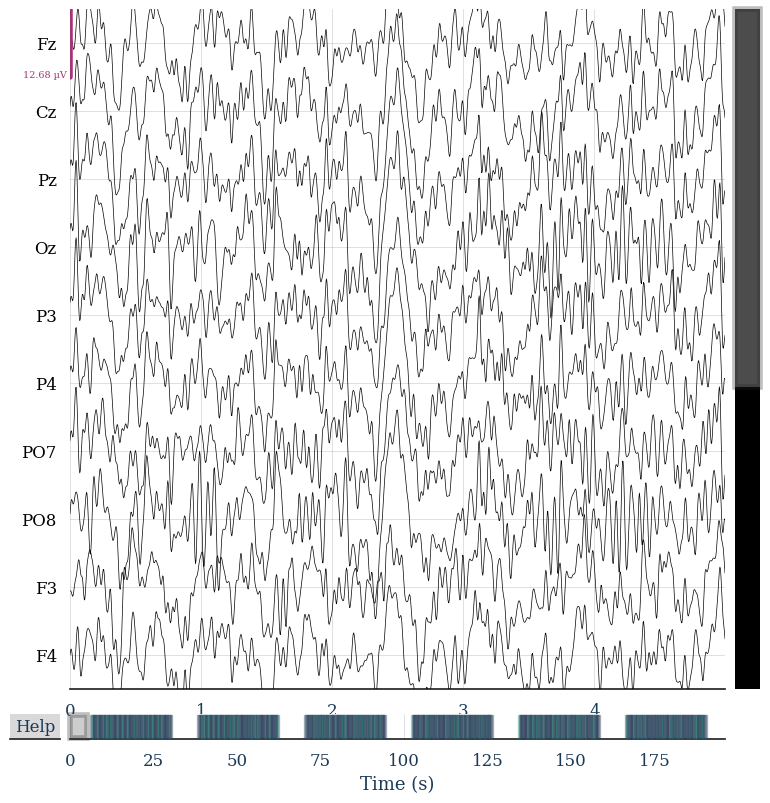

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


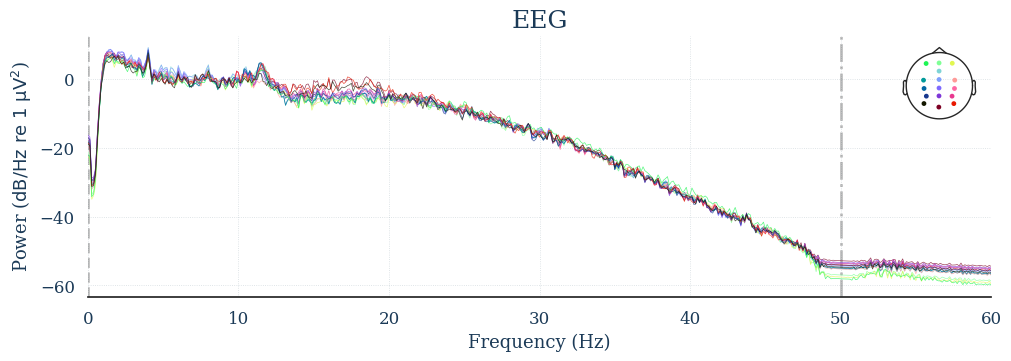

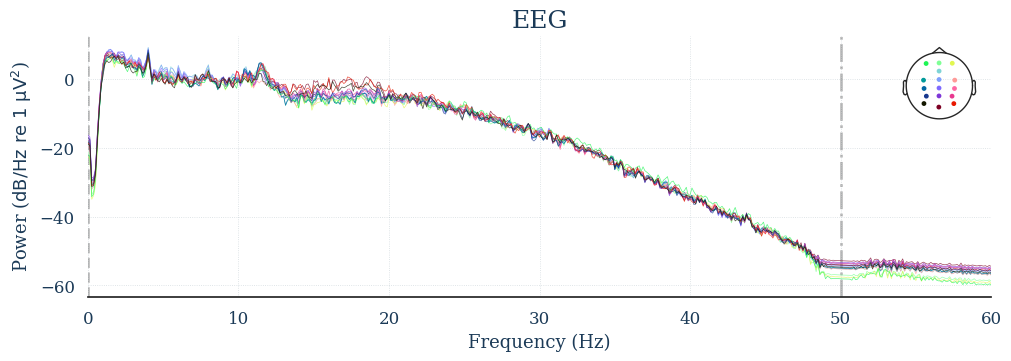

In [103]:
# RAW EEG VISUALIZATION
# Shows noisy brain signals before preprocessing
raw.plot(duration=5, n_channels=10, scalings='auto')
# PSD (Frequency domain)
raw.compute_psd(fmax=60).plot()

In [104]:
# PREPROCESSING
# Bandpass filter (0.1–30 Hz) → retains P300 frequency range
# Notch filter (50 Hz) → removes power-line noise
# Re-referencing → improves signal quality
raw_copy = raw.copy()

raw_copy.filter(l_freq=0.1, h_freq=30.0)
raw_copy.notch_filter(freqs=50)
raw_copy.set_eeg_reference('average')

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 8449 samples (33.004 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband e

<RawArray | 18 x 50184 (196.0 s), ~6.9 MiB, data loaded>

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


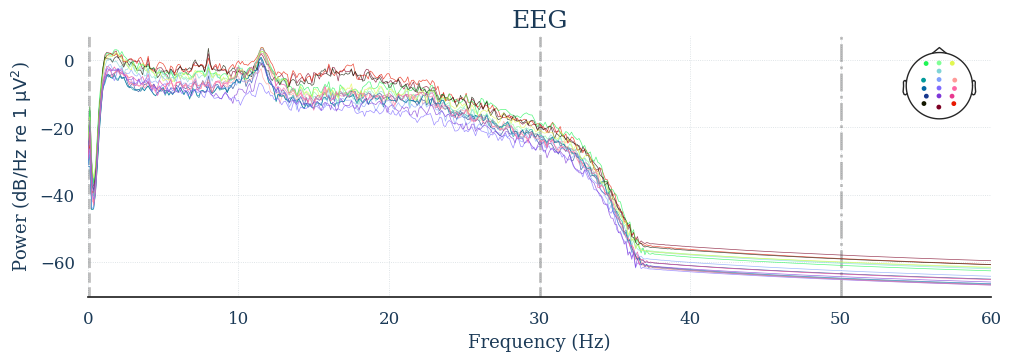

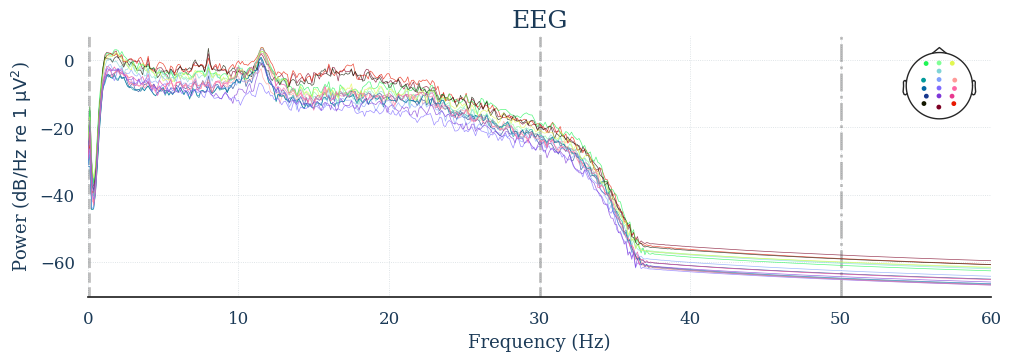

In [105]:
# PSD after filtering
raw_copy.compute_psd(fmax=60).plot()

Fitting ICA to data using 16 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 4.5s.


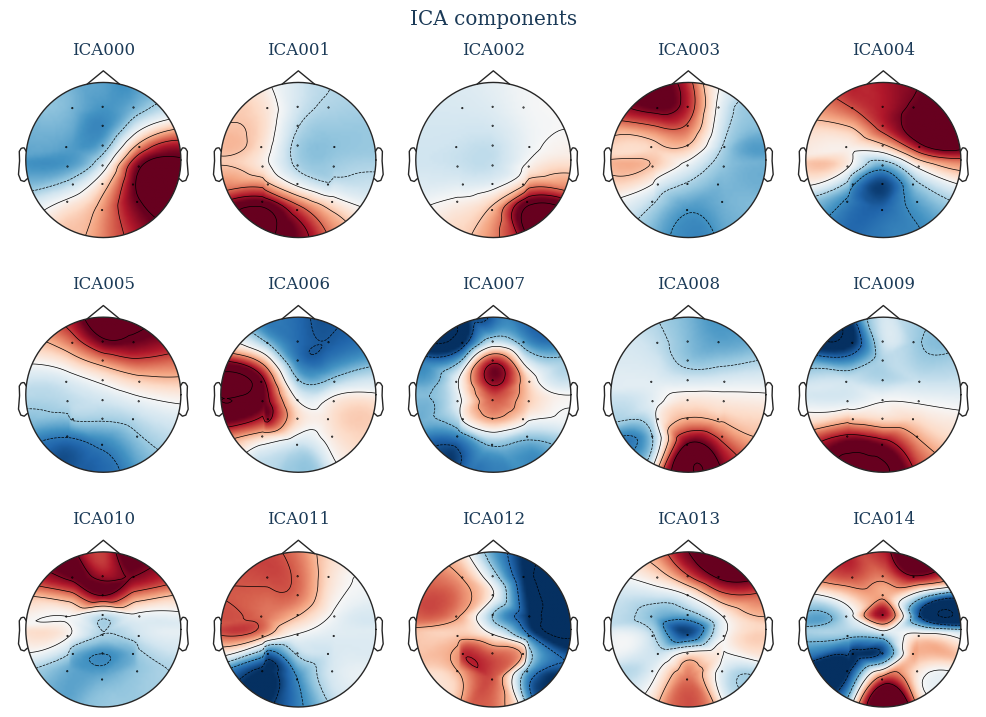

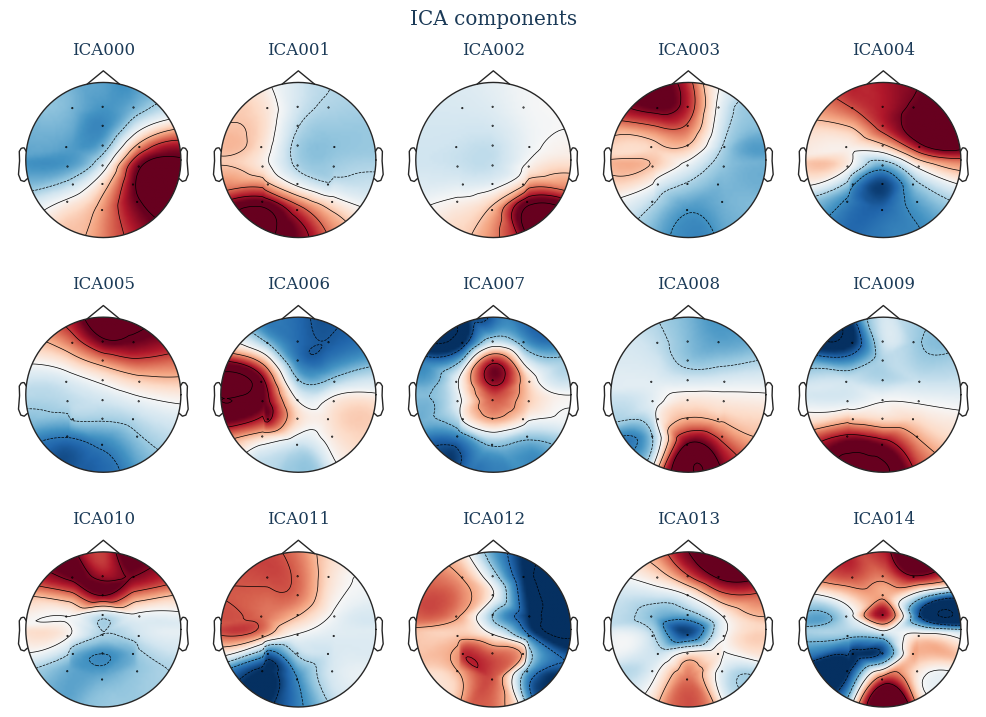

In [106]:
# ICA
# Removes eye blink and muscle artifacts
from mne.preprocessing import ICA

ica = ICA(n_components=15, random_state=97, max_iter='auto')
ica.fit(raw_copy)

ica.plot_components()

In [107]:
# Apply ICA after selecting artifact components manually
ica.exclude = [0, 1]
raw_clean = ica.apply(raw_copy)

Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 16 PCA components


In [108]:
# EPOCHING
# Extract time-locked EEG segments around stimulus
# Window: -200 ms to 800 ms (captures P300 response)
# No baseline → required for Xdawn
events, event_id = mne.events_from_annotations(raw_clean)

epochs = mne.Epochs(
    raw_clean,
    events,
    event_id=event_id,
    tmin=-0.2,
    tmax=0.8,
    baseline=None,
    preload=True
)

print(epochs)

Used Annotations descriptions: [np.str_('NonTarget'), np.str_('Target')]
Not setting metadata
576 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 576 events and 257 original time points ...
0 bad epochs dropped
<Epochs | 576 events (all good), -0.199 – 0.801 s (baseline off), ~20.4 MiB, data loaded,
 np.str_('NonTarget'): 480
 np.str_('Target'): 96>


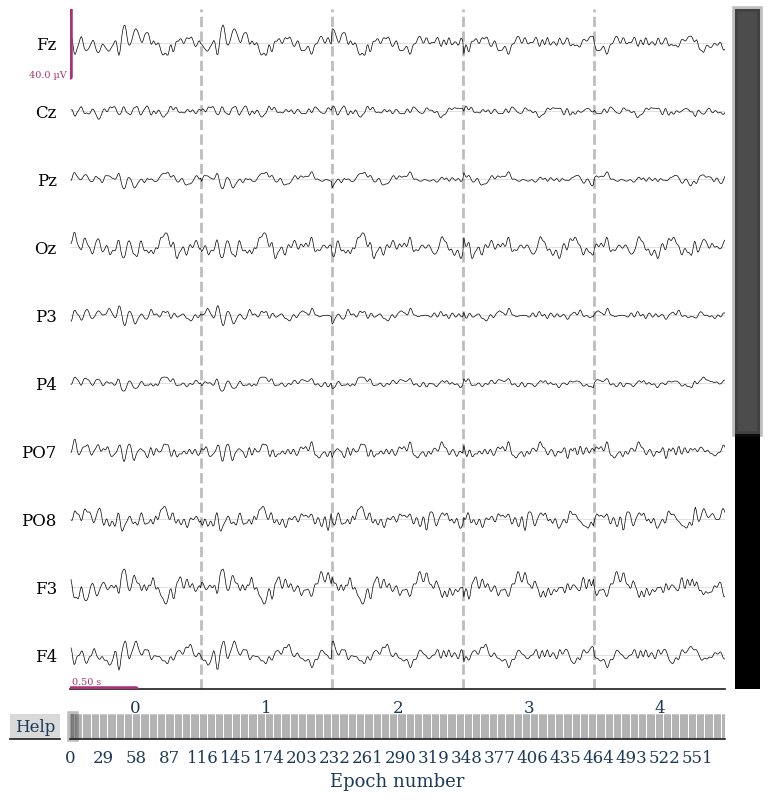

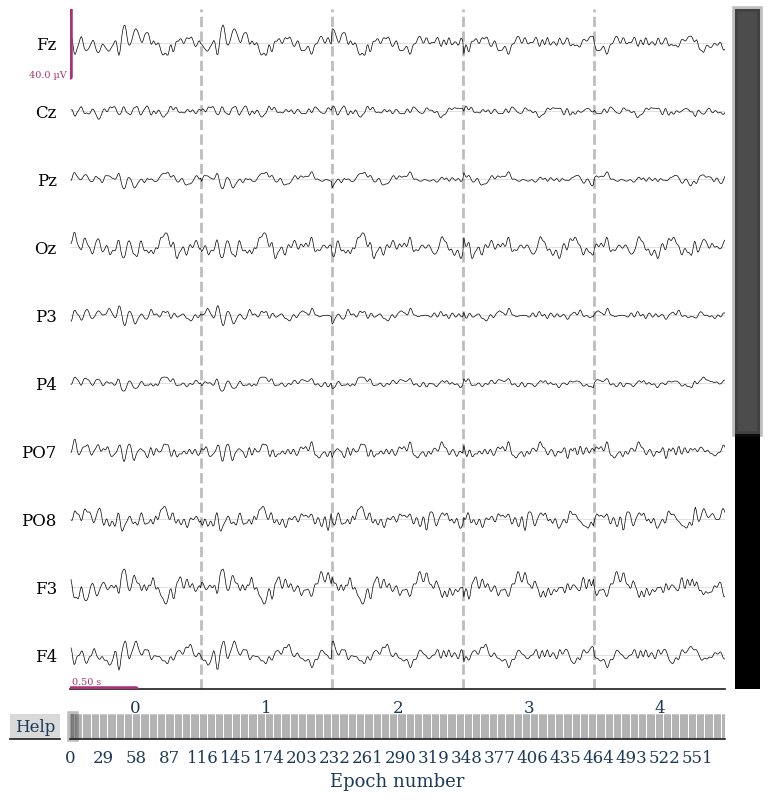

In [109]:
# Visualize epochs
epochs.plot(n_epochs=5, n_channels=10)

In [110]:
# LABELS
# Convert labels into binary classification
# 1 → Target (P300 present)
# 0 → Non-target
y = epochs.events[:, -1]
target_label = np.unique(y)[-1]
y_binary = (y == target_label).astype(int)

print("Class distribution:", np.bincount(y_binary))

Class distribution: [480  96]


In [111]:
# XDAWN SPATIAL FILTERING
# Enhances P300 signal and improves signal-to-noise ratio
epochs_eeg = epochs.copy().pick('eeg')

from mne.preprocessing import Xdawn

xdawn = Xdawn(n_components=6, reg=0.1)
epochs_xdawn = xdawn.fit_transform(epochs_eeg)

Estimating covariance using SHRINKAGE
Done.
Estimating covariance using SHRINKAGE
Done.
Estimating covariance using SHRINKAGE
Done.


In [112]:
# FEATURE MATRIX
# Flatten data into feature vectors for ML model
X = epochs_xdawn.reshape(epochs_xdawn.shape[0], -1)

print("Feature shape:", X.shape)

Feature shape: (576, 3084)


In [113]:
# TRAIN TEST SPLIT
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

In [114]:
# FEATURE SCALING
# Standardize features for better SVM performance
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [115]:
# SVM CLASSIFIER
# class_weight='balanced' handles class imbalance
svm = SVC(kernel='rbf', class_weight='balanced', probability=True)
svm.fit(X_train, y_train)

SVC(class_weight='balanced', probability=True)

In [116]:
# PREDICTION
y_prob = svm.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.3).astype(int)

In [117]:
# PERFORMANCE METRICS
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8448275862068966
              precision    recall  f1-score   support

           0       0.94      0.87      0.90        97
           1       0.52      0.74      0.61        19

    accuracy                           0.84       116
   macro avg       0.73      0.80      0.76       116
weighted avg       0.87      0.84      0.85       116



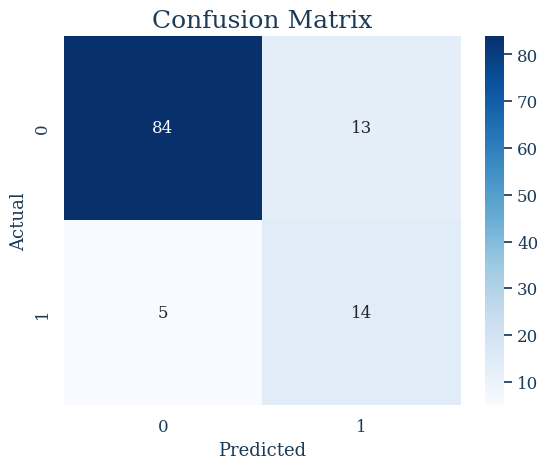

In [118]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [119]:
# ITR CALCULATION
# Measures efficiency of BCI system (bits per minute)
# Uses realistic trial time (T = 5 seconds)
def compute_itr(N, P, T):
    return (np.log2(N) + P*np.log2(P) + (1-P)*np.log2((1-P)/(N-1))) * 60 / T

N = 36
P = accuracy_score(y_test, y_pred)
T = 5

print("ITR (bits/min):", compute_itr(N, P, T))

ITR (bits/min): 45.016409501043356


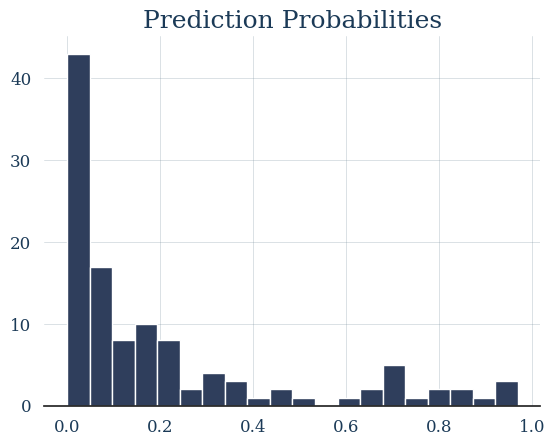

In [121]:
# Histogram of prediction probabilities
plt.hist(y_prob, bins=20)
plt.title("Prediction Probabilities")
plt.show()